In [44]:
from matplotlib import pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader
from dl_project import *

torch.Size([3, 218, 178])


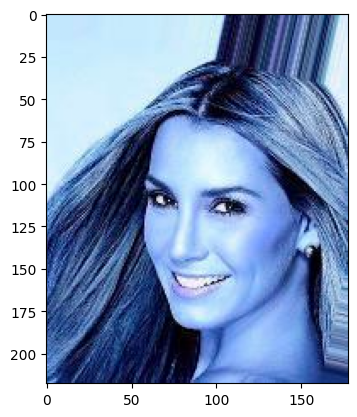

In [45]:
def convert_to_image(x):
    x = x[0].detach().numpy()
    x = np.clip(x, 0, 1) # clip image to valid color range
    return x

# load images
# all_images = image_augmentation()
all_images = load_dataset()
dataloader = DataLoader(all_images, batch_size=1, shuffle=True)

# display first image
image = next(iter(dataloader))
print(image[0].shape)
plt.imshow(image[0].permute(1, 2, 0))
plt.show()

In [46]:
def noise_schedule(beta_1, beta_T, T, type="linear"):
    if type == "linear":
        beta_t = torch.linspace(beta_1, beta_T, T)
    else:
        raise ValueError(f"Unknown schedule type: {type}")

    alpha_t = 1 - beta_t
    alpha_bar_t = torch.cumprod(alpha_t, 0) # product of all elements in alpha_t from 1 to t
    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)  # first term of noise equation
    sqrt_1_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)  # second term of noise equation
    one_over_sqrt_alpha_t = 1 / torch.sqrt(alpha_t)  # first term of sampling equation
    beta_t_over_sqrt_1_minus_alpha_bar_t = beta_t / sqrt_1_minus_alpha_bar_t  # second term of sampling equation
    return {
        "T": T,
        "beta_t": beta_t,
        "alpha_t": alpha_t,
        "alpha_bar_t": alpha_bar_t,
        "sqrt_alpha_bar_t": sqrt_alpha_bar_t,
        "sqrt_1_minus_alpha_bar_t": sqrt_1_minus_alpha_bar_t,
        "one_over_sqrt_alpha_t": one_over_sqrt_alpha_t,
        "beta_t_over_sqrt_1_minus_alpha_bar_t": beta_t_over_sqrt_1_minus_alpha_bar_t,
    }

# typical values
T = 1000
beta_1 = 0.0001
beta_T = 0.02

In [47]:
class DDPM(torch.nn.Module):
    def __init__(self, schedule):  # todo add parameters
        super(DDPM, self).__init__()
        self.schedule = schedule

    # adds noise to the input image
    def forward_diffusion(self, x, t):
        epsilon = torch.randn(x.shape) # noise
        alpha_bar_t = self.schedule["alpha_bar_t"][t]
        sqrt__1_minus_alpha_bar_t = self.schedule["sqrt_1_minus_alpha_bar_t"][t]
        return alpha_bar_t * x + sqrt__1_minus_alpha_bar_t * epsilon, epsilon


    # generates image from noise
    def generate_image(self, shape):
        # todo
        T = self.schedule["T"]
        x_t = torch.randn(shape)
        first_term = self.schedule["one_over_sqrt_alpha_t"]
        second_term = self.schedule["beta_t_over_sqrt_1_minus_alpha_bar_t"]
        for t in range(T, 0, -1):
            prediction = None  # todo predict using the model
            x_t = first_term[t] * (x_t - second_term[t] * prediction)
            if t > 1:
                z = torch.randn(shape)
                sigma_t = 1  # ! wtf is sigma_t
                x_t += sigma_t * z
        return x_t
    
    def train(self, mode = True):
        # todo
        pass

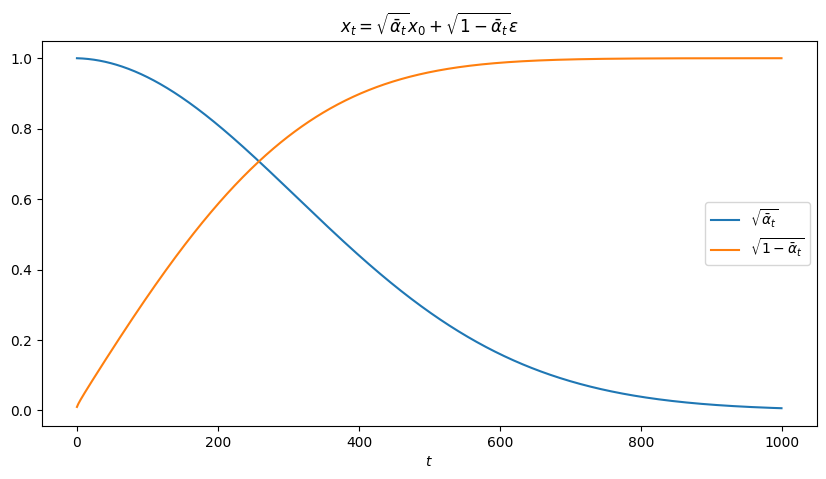

In [48]:
# test schedules by comparing it with the example in P12.ipynb
schedule = noise_schedule(1e-4, 0.02, 1000)
sqrt_alpha_bar = schedule['sqrt_alpha_bar_t']
sqrt_one_minus_alpha_bar = schedule['sqrt_1_minus_alpha_bar_t']

plt.figure(figsize=(10, 5))
plt.title(r'$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$')
plt.xlabel('$t$')
plt.plot(sqrt_alpha_bar, label=r'$\sqrt{\bar{\alpha}_t}$')
plt.plot(sqrt_one_minus_alpha_bar, label=r'$\sqrt{1-\bar{\alpha}_t}$')
plt.legend()
plt.show()

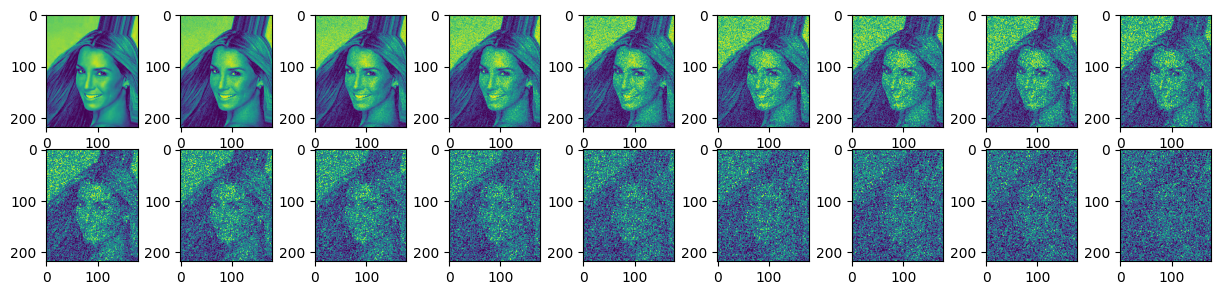

In [49]:
# test forward diffusion on a single image
T = 18
schedule = noise_schedule(beta_1, beta_T, T)
model = DDPM(schedule)
x_t = image[0]

# display image after each step
grid_width = 9
grid_height = T // grid_width
plt.figure(figsize=(grid_width * 1.7, grid_height * 1.6))
plt.axis('off')
assert T < 30, "Are you sure you want to display that many images?"
for t in range(0, T):
    plt.subplot(grid_height, grid_width, t + 1)
    x_t, noise = model.forward_diffusion(x_t, t)
    plt.imshow(convert_to_image(x_t))